# California Single-Family Residence — Close Price Prediction
## 03 · Baseline Linear Regression Model

Every model that follows has to prove it beats this one by a margin that isn't
noise, so the baseline needs to be simple, honest, and evaluated the same way
every later model will be. This notebook trains a Linear Regression on the
primary chronological split, evaluates it on the held-out validation month for
model-selection-style diagnostics, reports final metrics on test exactly once,
and checks whether those metrics hold up across the two rolling-origin backtest
cutoffs from `data_preprocessing.ipynb`.

**What "baseline" means here:** no hyperparameter search, no
feature engineering beyond what preprocessing already froze, no target
leakage. The point isn't to make Linear Regression look good, it's to set an
baseline that gradient boosting and geo-features have to clear.


In [7]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")


## Load the Frozen Splits & Feature Metadata

Which columns are features, which split is primary, which
months are available for backtesting, and the train-only outlier thresholds
was decided once in `data_preprocessing.ipynb` and saved to
`preprocessing_metadata.json`. This notebook reads that file rather than
re-deriving any of it.

In [8]:
with open(OUTPUT_DIR / "preprocessing_metadata.json", "r") as f:
    metadata = json.load(f)

TARGET_COL = metadata["target_col"]
PRIMARY_SPLIT = metadata["primary_split"]
BACKTEST_SPLITS = metadata["backtest_splits"]

numeric_features = metadata["numeric_features"] + metadata["missing_flag_cols"]
categorical_features = metadata["categorical_features"] + metadata["boolean_features"]


def load_split(label):
    suffix = label.replace("-", "")
    train_df = pd.read_csv(OUTPUT_DIR / f"train_{suffix}_split.csv", low_memory=False)
    val_df = pd.read_csv(OUTPUT_DIR / f"val_{suffix}_split.csv", low_memory=False)
    test_df = pd.read_csv(OUTPUT_DIR / f"test_{suffix}_split.csv", low_memory=False)

    keep_numeric = [c for c in numeric_features if c in train_df.columns]
    keep_categorical = [c for c in categorical_features if c in train_df.columns]
    feature_cols = keep_numeric + keep_categorical

    return train_df, val_df, test_df, feature_cols, keep_numeric, keep_categorical


train_df, val_df, test_df, feature_cols, numeric_features, categorical_features = load_split(PRIMARY_SPLIT)

print(f"Primary split: test={PRIMARY_SPLIT}, backtest cutoffs={BACKTEST_SPLITS}")
print(f"Train: {train_df.shape}  Val: {val_df.shape}  Test: {test_df.shape}")
print(f"Feature columns: {len(feature_cols)}")


Primary split: test=2026-06, backtest cutoffs=['2026-05', '2026-04']
Train: (382529, 42)  Val: (11887, 42)  Test: (12696, 42)
Feature columns: 34


In [9]:
X_train, y_train = train_df[feature_cols].copy(), train_df[TARGET_COL].copy()
X_val, y_val = val_df[feature_cols].copy(), val_df[TARGET_COL].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[TARGET_COL].copy()

print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)


X_train: (382529, 34)  X_val: (11887, 34)  X_test: (12696, 34)


## Preprocessing Pipeline

This is the *only* place imputation, scaling, and encoding
happens,  wrapped in a `Pipeline`/`ColumnTransformer` which gaurds against leakage


- **Numeric features:** median imputation (robust to the outliers we already
  saw in exploration), then standardized — Linear Regression's coefficients
  and convergence are sensitive to feature scale.
- **Categorical + boolean features:** missing are set to `"Unknown"`, then one-hot encoded with `handle_unknown="ignore"` so a
  category seen only in validation/test at prediction time doesn't crash the
  pipeline, it's just encoded as all-zeros instead.


In [10]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])


## Log-Transformed Target

`data_exploration.ipynb` found `ClosePrice` skewness of ~140 (heavily inflated
by a handful of inaccurate rows we traced there), dropping to ~0.46
after `log1p` (a roughly symmetric distribution). Linear Regression assumes
errors are homoscedastic and roughly normal, which holds much better in
log-space for multi-scale price data.

`TransformedTargetRegressor` applies `log1p` before fitting and `expm1` before
returning predictions, so every metric below is computed in
**original dollar space**: R²/MAE/RMSE/MAPE/MdAPE all mean what they say,
not in log-dollars.


In [11]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1,
    )),
])

baseline_model.fit(X_train, y_train)
print("Fitted.")


Fitted.


## Metrics

- **R²**:overall variance explained; sensitive to a few large-error properties.
- **MAE**: dollar-denominated average error; intuitive for stakeholders.
- **RMSE**: squares errors before averaging, so large misses dominate; useful
  when big misses carry outsized cost.
- **MAPE**: average *percentage* error; still pulled by outlier percentage
  errors on very low-priced properties.
- **MdAPE**: *median* percentage error; robust to outliers and the most
  representative "typical error" figure for this data. This is the headline
  metric used to compare models starting here.


In [12]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs(y_true - y_pred) / y_true
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mape": float(np.mean(ape) * 100),
        "mdape": float(np.median(ape) * 100),
    }


def price_band_errors(y_true, y_pred, n_bands=5):
    df = pd.DataFrame({"actual": np.asarray(y_true, dtype=float), "pred": np.asarray(y_pred, dtype=float)})
    df["ape"] = np.abs(df["actual"] - df["pred"]) / df["actual"]
    df["price_band"] = pd.qcut(df["actual"], q=n_bands, labels=[f"Q{i+1}" for i in range(n_bands)], duplicates="drop")
    return df.groupby("price_band", observed=True).agg(
        n=("ape", "size"),
        median_price=("actual", "median"),
        mape=("ape", lambda s: s.mean() * 100),
        mdape=("ape", lambda s: s.median() * 100),
    )


In [14]:
val_pred = baseline_model.predict(X_val)
val_metrics = regression_metrics(y_val, val_pred)

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"  {k.upper():6s}: {v:,.3f}")


Validation metrics:
  R2    : 0.810
  MAE   : 219,009.686
  RMSE  : 428,072.704
  MAPE  : 15.442
  MDAPE : 11.405


## Test set Performance Metrics


In [15]:
test_pred = baseline_model.predict(X_test)
test_metrics = regression_metrics(y_test, test_pred)

print(f"Baseline Linear Regression — Test Set ({PRIMARY_SPLIT})")
for k, v in test_metrics.items():
    print(f"  {k.upper():6s}: {v:,.3f}")

price_band_errors(y_test, test_pred)


Baseline Linear Regression — Test Set (2026-06)
  R2    : 0.813
  MAE   : 214,186.657
  RMSE  : 425,117.455
  MAPE  : 15.402
  MDAPE : 11.211


,n,median_price,mape,mdape
price_band,,,,
Q1,2542,450000.0,16.179766,9.948971
Q2,2543,699000.0,12.801256,9.056411
Q3,2557,925000.0,13.511113,9.924550
Q4,2523,1335000.0,14.964967,11.849673
Q5,2531,2335000.0,19.578019,16.684434


## Interpreting the Baseline Results

1.**Validation and test are close** R² 0.810 vs 0.813, MdAPE 11.4% vs 11.2%. 
That consistency means the pipeline isn't overfit to one
particular month, and the validation metrics were a trustworthy preview of
test performance before test was ever touched.

2.**R² of ~0.81** means the model explains about 81% of the variance in
`ClosePrice` using only property characteristics, location, and structural
features. For a linear model with no
feature engineering yet, that's a reasonable floor and shows that intrinsic property
characteristics carry real signal, but a fifth of the variance is
still unexplained.

3.**The gap between MAPE (15.4%) and MdAPE (11.2%) is reflective of the right-skew.**
Since MdAPE (median) is lower than MAPE (mean), the error
distribution is **right-skewed**. Most predictions are considerably better than
15% off, but a small number of properties are missed badly enough to pull
the average up. A right-skewed, multi-scale target produces a
right-skewed error distribution too, which is exactly why MdAPE (11.2%) is
the more representative "typical error" figure and MAPE alone would overstate
how badly the model performs on a typical home.

4.**In dollar terms**, MAE of ~$214K and
RMSE of ~$425K being roughly double MAE is another sign of a right-skewed error
tail: RMSE's squaring penalizes the handful of large misses much more than
MAE does, so the gap between them is a rough proxy for how much a small
number of hard-to-predict properties (likely luxury homes) are dragging the metrics.

## Residual Diagnostics

- **predicted-vs-residual**: checks for patterns a linear model is missing

- **residual distribution**: checks symmetry

- **actual-vs-predicted**:checks calibration acrossthe price range


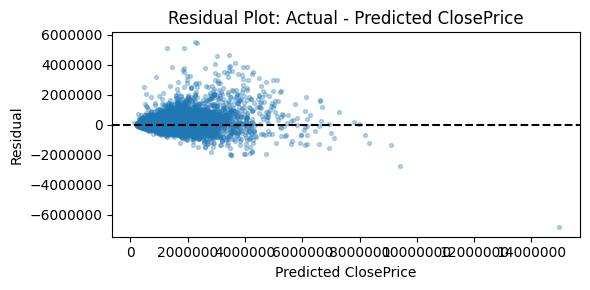

In [16]:
residuals = y_test.to_numpy() - test_pred

plt.figure(figsize=(6, 3))
plt.scatter(test_pred, residuals, alpha=0.3, s=8)
plt.axhline(0, linestyle="--", color="black")
plt.title("Residual Plot: Actual - Predicted ClosePrice")
plt.xlabel("Predicted ClosePrice")
plt.ylabel("Residual")
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


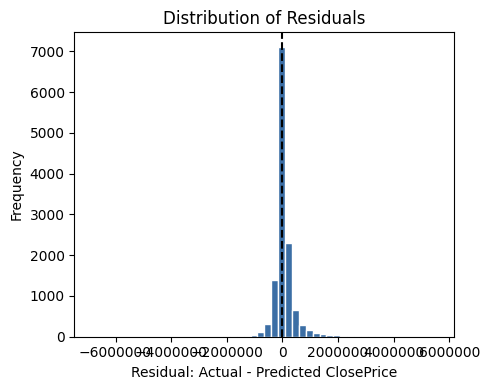

In [21]:
plt.figure(figsize=(5, 4))
plt.hist(residuals, bins=50, color="#3b6ea5", edgecolor="white")
plt.axvline(0, linestyle="--", color="black")
plt.title("Distribution of Residuals")
plt.xlabel("Residual: Actual - Predicted ClosePrice")
plt.ylabel("Frequency")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()


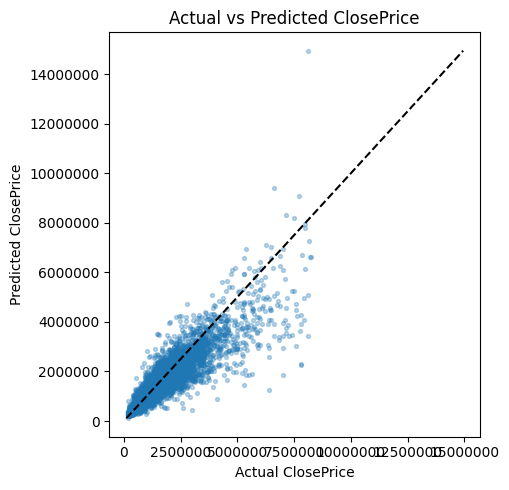

In [19]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, test_pred, alpha=0.3, s=8)
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(lims, lims, linestyle="--", color="black")
plt.title("Actual vs Predicted ClosePrice")
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.ticklabel_format(style="plain", axis="both")
plt.tight_layout()
plt.show()


## Interpreting the Residual Diagnostics

1. **The residual-vs-predicted plot shows classic heteroscedasticity** — the
spread of residuals visibly widens as predicted price increases. Near the low
end, residuals hug tightly around zero; by the
time predictions reach $4-6M, the scatter fans out to several million dollars
in either direction.

2. **The residual histogram shows a sharp, tight peak near zero** — the bulk of
predictions are close to actual — **with a mild right skew**, a longer tail
of underprediction (positive residuals) than overprediction. Combined with
the actual-vs-predicted plot, where points at the higher end of the price
range tend to fall *above* the diagonal, this suggests the model
systematically underpredicts higher-priced homes.

## Rolling-Origin Backtest

A single train/test cutoff can be lucky or unlucky. Here the identical
pipeline is refit on each of the earlier backtest cutoffs saved by
`data_preprocessing.ipynb`, and metrics are compared across all three cutoffs.


In [22]:
def fit_and_evaluate(split_label):
    tr_df, va_df, te_df, feats, num_feats, cat_feats = load_split(split_label)
    X_tr, y_tr = tr_df[feats], tr_df[TARGET_COL]
    X_te, y_te = te_df[feats], te_df[TARGET_COL]

    pipe = Pipeline(steps=[
        ("preprocess", ColumnTransformer(transformers=[
            ("numeric", numeric_pipeline, num_feats),
            ("categorical", categorical_pipeline, cat_feats),
        ])),
        ("model", TransformedTargetRegressor(
            regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1,
        )),
    ])
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)
    metrics = regression_metrics(y_te, preds)
    metrics["test_month"] = split_label
    metrics["train_rows"] = len(X_tr)
    metrics["test_rows"] = len(X_te)
    return metrics


backtest_results = [fit_and_evaluate(PRIMARY_SPLIT)]
for cutoff in BACKTEST_SPLITS:
    backtest_results.append(fit_and_evaluate(cutoff))

backtest_df = pd.DataFrame(backtest_results)[
    ["test_month", "train_rows", "test_rows", "r2", "mae", "rmse", "mape", "mdape"]
]
backtest_df


,test_month,train_rows,test_rows,r2,mae,rmse,mape,mdape
0,2026-06,382529,12696,0.813498,214186.656817,425117.455400,15.401627,11.210950
1,2026-05,370636,11886,0.808832,219268.504300,428806.844223,15.453627,11.437032
2,2026-04,359593,11878,0.804313,219825.490688,436880.375859,15.724500,11.377050


### Results 

These metrics confirm that the baseline linear regression model is stable and generalizes well to new, unseen data over time. This shows the validation split matches future data patterns and avoids data leakage.

## Save Model, Preprocessing Artifacts, and Metrics

The trained pipeline is saved as a single artifact
(preprocessing + model together, since they're one `Pipeline` object) so
`app.py` can load it directly without redefining feature lists or
transformation logic.


In [23]:
model_path = OUTPUT_DIR / "baseline_linear_regression_model.joblib"
joblib.dump({
    "pipeline": baseline_model,
    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_col": TARGET_COL,
}, model_path)

metrics_df = pd.DataFrame([{
    "model": "Linear Regression (log-target)",
    "split": PRIMARY_SPLIT,
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    **test_metrics,
}])

metrics_path = OUTPUT_DIR / "baseline_linear_regression_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)
backtest_df.to_csv(OUTPUT_DIR / "baseline_linear_regression_backtest.csv", index=False)

print("Saved model to:", model_path)
print("Saved metrics to:", metrics_path)
metrics_df


Saved model to: outputs/baseline_linear_regression_model.joblib
Saved metrics to: outputs/baseline_linear_regression_metrics.csv


,model,split,train_rows,val_rows,test_rows,r2,mae,rmse,mape,mdape
0,Linear Regression (log-target),2026-06,382529,11887,12696,0.813498,214186.656817,425117.4554,15.401627,11.21095


## Summary

- Linear Regression on a log-transformed target, evaluated on R², MAE, RMSE,
  MAPE, and MdAP.
- Backtested across 3 chronological cutoffs to check stability, not just a
  single validation set.

Next notebook: [`model_comparison.ipynb`](./model_comparison.ipynb) — Decision
Tree and Random Forest, compared against this baseline on the same splits and
the same metric set
